In [17]:
# opening a sample audio file to check sample rate and duration

import librosa
import sys
sys.path.append('..')

from config import DATA_PATH
from pathlib import Path
from collections import Counter

DRYAD_PATH = Path(DATA_PATH) / "dryad"
TRAIN_PATH = Path(DATA_PATH) / "train"
TEST_PATH = Path(DATA_PATH) / "test"

In [ ]:
y, sr = librosa.load(TRAIN_PATH / "DBA_9863_159.WAV", sr=None)
print(f"Sample rate: {sr}")
print(f"Duration: {len(y)/sr:.4f} seconds")

# getting train-test split breakdown
train_files = list(TRAIN_PATH.glob("*.WAV")) + list(TRAIN_PATH.glob("*.wav"))
test_files = list(TEST_PATH.glob("*.WAV")) + list(TEST_PATH.glob("*.wav"))

print(f"Train files: {len(train_files)}")
print(f"Test files: {len(test_files)}")
print(f"Total: {len(train_files) + len(test_files)}")
print(f"Train/test split: {len(train_files)/(len(train_files)+len(test_files))*100:.1f}% / {len(test_files)/(len(train_files)+len(test_files))*100:.1f}%")

Train files: 20265
Test files: 2251
Total: 22516
Train/test split: 90.0% / 10.0%


Matplotlib is building the font cache; this may take a moment.


Min duration:    8.0 ms
Max duration:    409.6 ms
Mean duration:   55.7 ms
Median duration: 46.4 ms


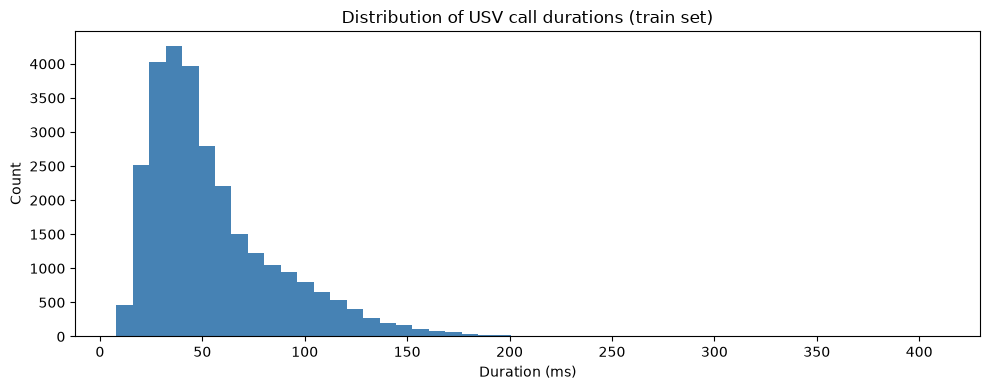

In [ ]:
# analyzing duration distribution of train set

import matplotlib.pyplot as plt
import numpy as np

# compute durations of all train files
durations = []
for f in train_files:
    y, sr = librosa.load(f, sr=None)
    durations.append(len(y) / sr)

durations = np.array(durations)

# print stats
print(f"Min duration:    {durations.min()*1000:.1f} ms")
print(f"Max duration:    {durations.max()*1000:.1f} ms")
print(f"Mean duration:   {durations.mean()*1000:.1f} ms")
print(f"Median duration: {np.median(durations)*1000:.1f} ms")

# make histogram of durations
plt.figure(figsize=(10, 4))
plt.hist(durations * 1000, bins=50, color='steelblue', edgecolor='none')
plt.xlabel("Duration (ms)")
plt.ylabel("Count")
plt.title("Distribution of USV call durations (train set)")
plt.tight_layout()
plt.show()

Min RMS:    0.002372
Max RMS:    0.669853
Mean RMS:   0.046029


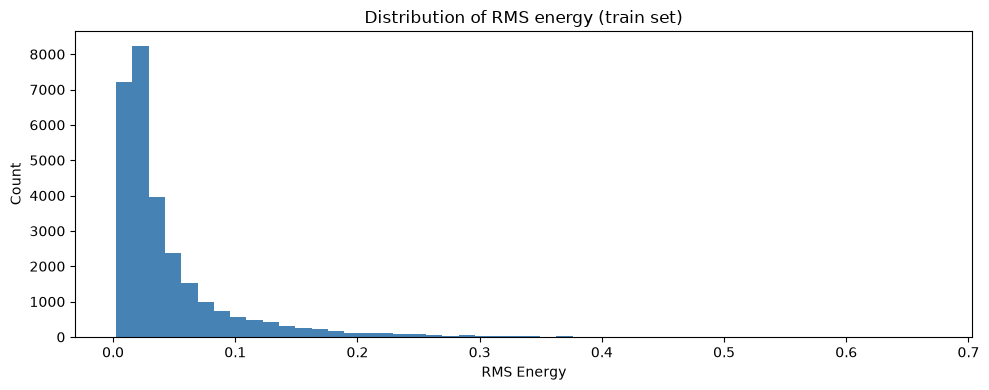


Bottom 5% threshold: 0.007766
Quiet files:
  C57_3535_232.WAV: 0.002372
  C57_3532_170.WAV: 0.002372
  C57_3532_212.WAV: 0.002442
  C57_3532_178.WAV: 0.002467
  C57_3532_171.WAV: 0.002483
  C57_3535_216.WAV: 0.002492
  C57_3532_176.WAV: 0.002518
  C57_3532_177.WAV: 0.002550
  C57_3532_193.WAV: 0.002557
  C57_3532_210.WAV: 0.002569


In [ ]:
# analyzing RMS energy distribution of train set
# rms: root mean square energy, a measure of signal strength (loudness)

# compute RMS energy of all train files
rms_values = []
for f in train_files:
    y, sr = librosa.load(f, sr=None)
    rms = np.sqrt(np.mean(y**2))
    rms_values.append((f.name, rms))

rms_values.sort(key=lambda x: x[1])
rms_array = np.array([r for _, r in rms_values])

# print stats
print(f"Min RMS:    {rms_array.min():.6f}")
print(f"Max RMS:    {rms_array.max():.6f}")
print(f"Mean RMS:   {rms_array.mean():.6f}")

# make figure
plt.figure(figsize=(10, 4))
plt.hist(rms_array, bins=50, color='steelblue', edgecolor='none')
plt.xlabel("RMS Energy")
plt.ylabel("Count")
plt.title("Distribution of RMS energy (train set)")
plt.tight_layout()
plt.show()

# print bottom 5% of RMS values
threshold = np.percentile(rms_array, 5)
print(f"\nBottom 5% threshold: {threshold:.6f}")
print(f"Quiet files:")
for name, rms in rms_values[:10]:
    print(f"  {name}: {rms:.6f}")

In [16]:
c57_rms = [rms for name, rms in rms_values if name.startswith('C57')]
dba_rms = [rms for name, rms in rms_values if name.startswith('DBA')]

print(f"C57 mean RMS: {np.mean(c57_rms):.6f}")
print(f"DBA mean RMS: {np.mean(dba_rms):.6f}")

C57 mean RMS: 0.037512
DBA mean RMS: 0.049418


In [ ]:
c57_test = [f for f in test_files if f.name.startswith('C57')]
dba_test = [f for f in test_files if f.name.startswith('DBA')]

# print(f"Train (C57): {len(c57_files)} | DBA: {len(dba_files)}")
# print(f"Test (C57): {len(c57_test)} | DBA: {len(dba_test)}")
# print(f"Train C57 ratio: {len(c57_files)/(len(c57_files)+len(dba_files))*100:.1f}%")
# print(f"Test  C57 ratio: {len(c57_test)/(len(c57_test)+len(dba_test))*100:.1f}%")

Train — C57: 8064 | DBA: 20265
Test  — C57: 895 | DBA: 2251
Train C57 ratio: 28.5%
Test  C57 ratio: 28.4%


In [ ]:
# getting rid of the C57 strain

import os

c57_train = [f for f in train_files if f.name.startswith('C57')]
c57_test = [f for f in test_files if f.name.startswith('C57')]

for f in c57_train + c57_test:
    os.remove(f)

print(f"Deleted {len(c57_train)} C57 train files")
print(f"Deleted {len(c57_test)} C57 test files")

Deleted 8064 C57 train files
Deleted 895 C57 test files


In [6]:
from pathlib import Path
import soundfile as sf
import pandas as pd

# create a CSV file with the inventory of the train set
# include path, size, duration, and sample rate
rows = []
for p in sorted(TRAIN_PATH.glob("*.WAV")):
    stat = p.stat()
    try:
        info = sf.info(p)
        duration = info.frames / info.samplerate
        sr = info.samplerate
    except Exception:
        duration = None
        sr = None
    rows.append({"path": str(p), "size_bytes": stat.st_size, "duration_s": duration, "sr": sr})
pd.DataFrame(rows).to_csv("eda_train_inventory.csv", index=False)

          size_bytes    duration_s        sr
count   20265.000000  20265.000000   20265.0
mean    28449.372909      0.056811  250000.0
std     15490.651020      0.030981       0.0
min      4046.000000      0.008004  250000.0
25%     17644.000000      0.035200  250000.0
50%     24046.000000      0.048004  250000.0
75%     36046.000000      0.072004  250000.0
max    107246.000000      0.214404  250000.0


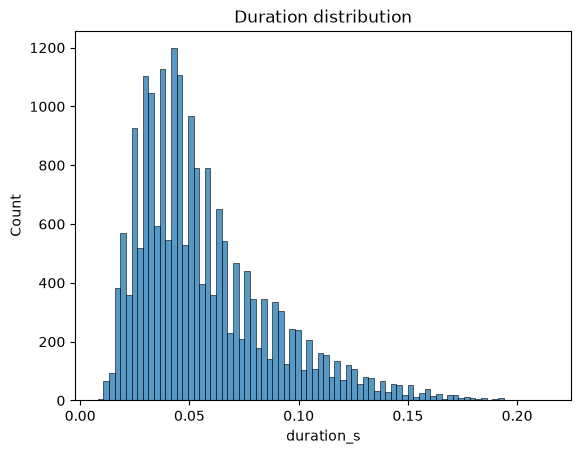

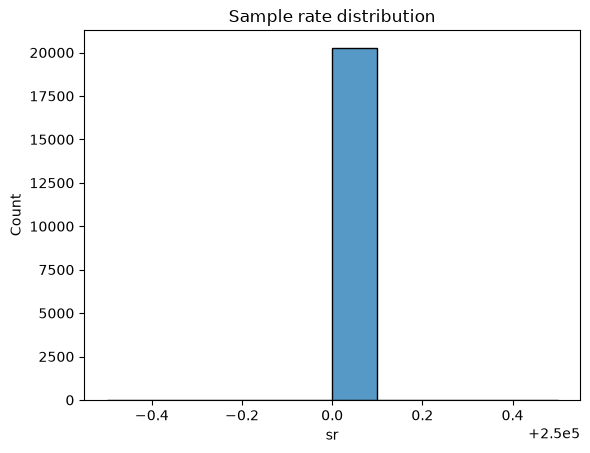

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# analyze the inventory CSV file
df = pd.read_csv("eda_train_inventory.csv")
print(df[["size_bytes","duration_s","sr"]].describe())
sns.histplot(df["duration_s"].dropna(), bins=80)
plt.title("Duration distribution")
plt.show()
sns.histplot(df["sr"].dropna(), bins=10)
plt.title("Sample rate distribution")
plt.show()

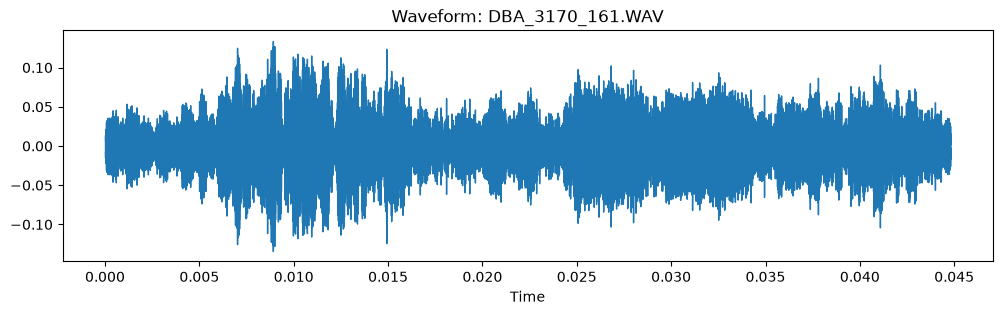

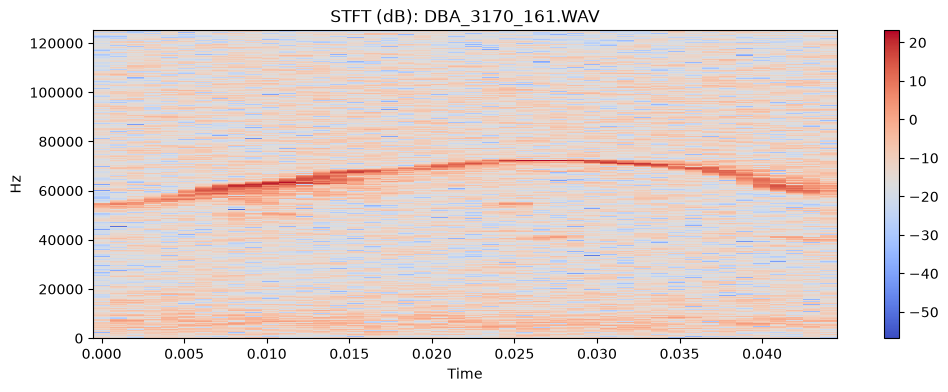

In [9]:
import random, librosa, librosa.display, matplotlib.pyplot as plt
from pathlib import Path

# open a random audio file from the train set and display its waveform
p = random.choice(list(TRAIN_PATH.glob("*.WAV")))
y, sr = librosa.load(p, sr=None)
plt.figure(figsize=(12,3))
librosa.display.waveshow(y, sr=sr)
plt.title(f"Waveform: {p.name}")
plt.show()

# compute and display the STFT (Short-Time Fourier Transform) of the audio signal
D = librosa.stft(y, n_fft=1024, hop_length=256)
S_db = librosa.amplitude_to_db(abs(D))
plt.figure(figsize=(12,4))
librosa.display.specshow(S_db, sr=sr, hop_length=256, x_axis="time", y_axis="hz")
plt.title(f"STFT (dB): {p.name}")
plt.colorbar()
plt.show()

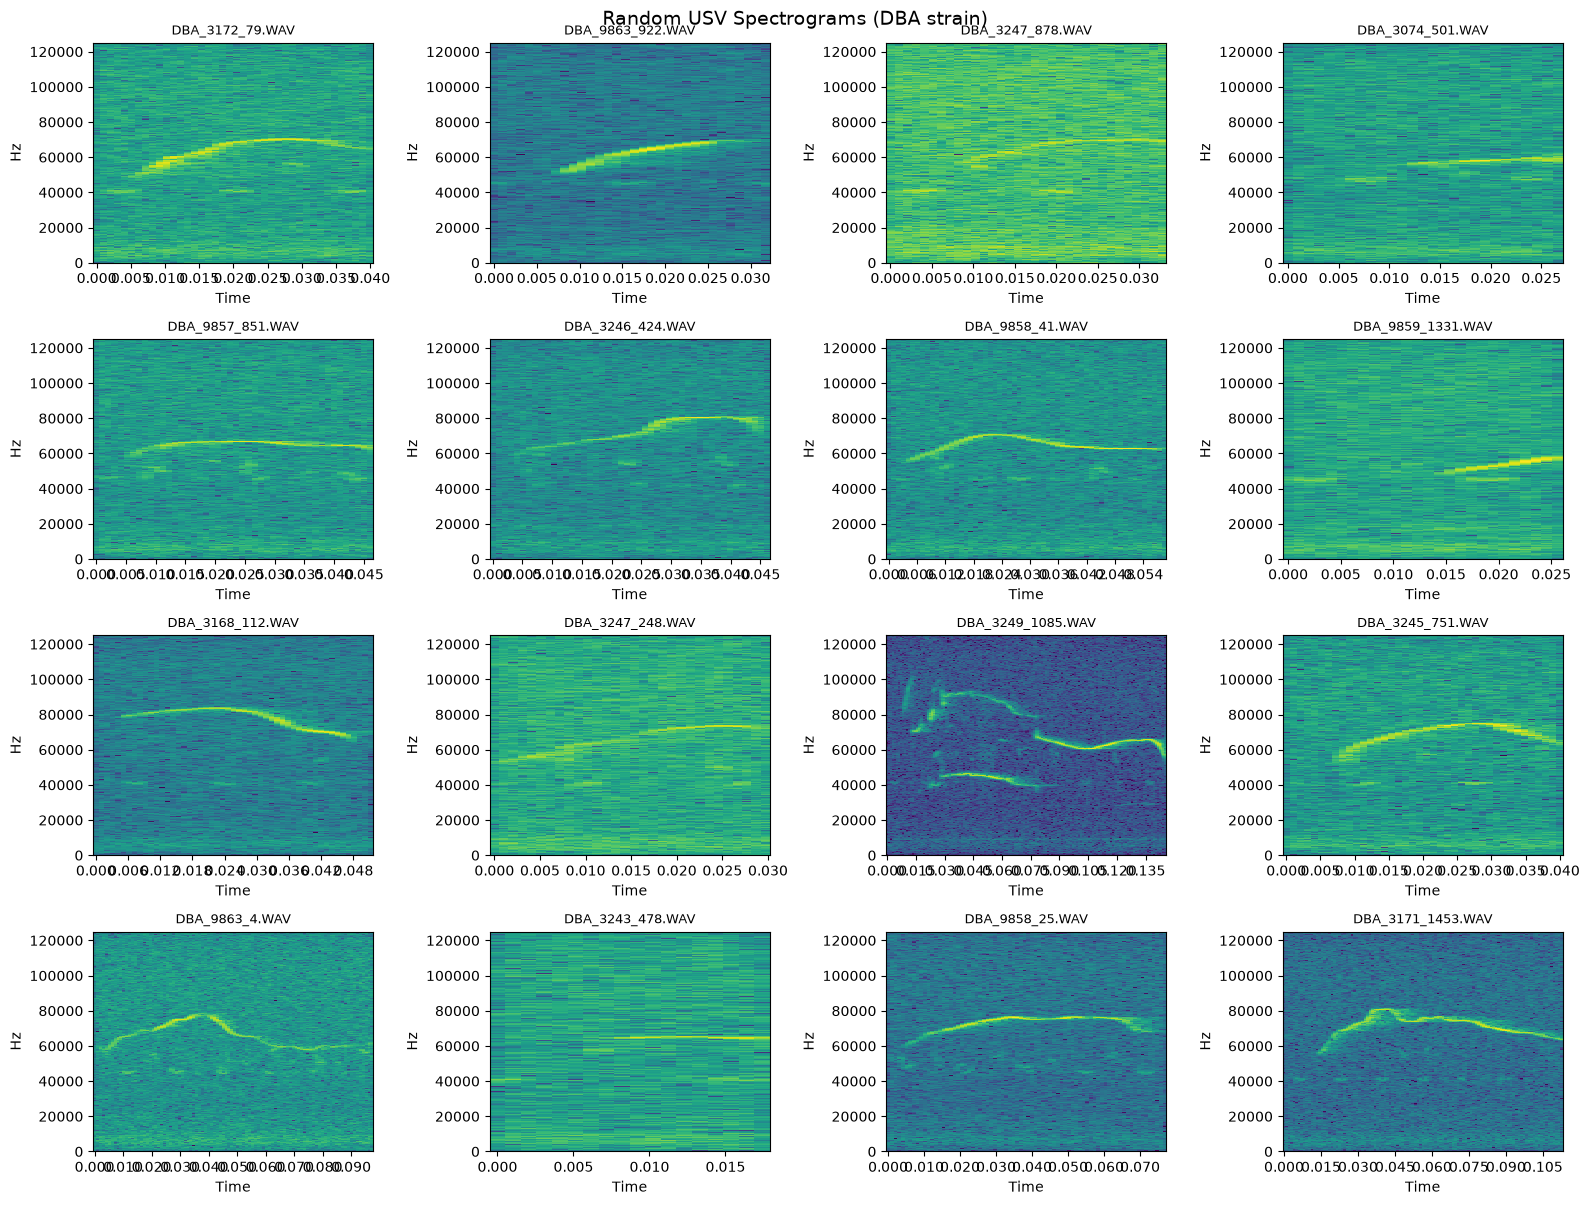

In [ ]:
import random
import matplotlib.pyplot as plt
import librosa
import librosa.display
import numpy as np

# sample 16 random files from train set
random_files = random.sample(list(TRAIN_PATH.glob("*.WAV")), 16)

# create a 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, filepath in enumerate(random_files):
    y, sr = librosa.load(filepath, sr=None)
    
    # compute spectrogram
    D = librosa.stft(y, n_fft=1024, hop_length=256)
    S_db = librosa.amplitude_to_db(abs(D), ref=np.max)
    
    # plot
    ax = axes[idx]
    librosa.display.specshow(S_db, sr=sr, hop_length=256, x_axis="time", y_axis="hz", ax=ax, cmap="viridis")
    ax.set_title(filepath.name, fontsize=9)
    ax.set_ylim([0, 125000])  # b/c usvs are in the 50-150 khz range

plt.tight_layout()
plt.suptitle("Random USV Spectrograms (DBA strain)", y=1.00, fontsize=14)
plt.show()

In [13]:
# see what file types are actually present in the dryad folder
files = list(DRYAD_PATH.iterdir())

print("Total files:", len(files))
print("By extension:")
for ext, count in Counter(f.suffix.lower() for f in files).items():
    print(f"  {ext}: {count}")

print("\nFirst 20 files:")
for f in files[:20]:
    print(f.name, f.stat().st_size)

Total files: 346
By extension:
  .txt: 183
  .wav: 117
  .xlsx: 44
  .csv: 1
  : 1

First 20 files:
09-May-2022_263_0_7.txt 1509604
266_bl.wav 240000044
28-Sep-2022_242_1_4_opto.txt 15926388
06-May-2022_262_1_3_opto.txt 15946995
09-May-2022_263_0_4.wav 40000044
09-May-2022_263_0_16.txt 1510548
09-May-2022_263_0_15.wav 40000044
01-May-2023taptest.txt 1135275
02-Apr-2024emg_6503_ch1_larynx_ch2_dia_emg2.txt 61988799
30-Sep-2022_208_1_4.wav 40000044
13-Feb-2023_213_10_4.txt 1512355
09-May-2022_263_0_6.txt 1509637
20-Dec-2022_206_10_4.txt 1512706
09-May-2022_263_0_4.txt 1509393
266_bl.txt 5667367
09-May-2022_263_0_7.wav 40000044
13-Feb-2023_213_1_4_opto.txt 15920160
23-May-2022_262_1_13_opto.txt 15846792
09-May-2022_263_0_15.txt 1510258
09-May-2022_263_0_16.wav 40000044


In [14]:
# looking at some of the text files in the dryad folder
for p in sorted(DRYAD_PATH.glob("*.txt"))[:5]:
    print(f"\n--- {p.name} ---")
    with open(p, "r", errors="ignore") as fh:
        for i, line in enumerate(fh):
            print(line.rstrip())
            if i >= 8:
                break

# that's not good!!! :( -> issue to do w/ how files were downloaded?


--- 01-Apr-2024emg_7028_ch1_larynx_ch2_dia.txt ---
-0.843926294156407
-0.84602062008398
-0.846181722079008
-0.847309436046599
-0.84698723205543
-0.846826130059974
-0.847792742033997
-0.847470538042313
-0.84698723205543

--- 01-Apr-2024emg_7028_ch1_larynx_ch2_dia_emg.txt ---
-0.0244010213664192
-0.00361887920333696
0.0132968184146906
0.0145856334909
0.0216741164611097
0.0361732864489721
0.0232851353301617
0.0218352183478101
0.0100747807365003

--- 01-Apr-2024emg_7028_ch1_larynx_ch2_dia_emg2.txt ---
-0.0287507719689945
-0.0551714787582469
-0.0543659694188982
-0.0553325806260152
-0.0509828301843362
-0.0234344101176126
-0.0131238900428305
0.00701384495839782
0.0456782980935775

--- 01-May-2023taptest.txt ---
-1.25747546209784
-1.25811987127113
-1.25876428044679
-1.25940868962481
-1.26134191717309
-1.26101971258023
-1.26295294014631
-1.26166412176654
-1.26150301946974

--- 02-Apr-2024emg_6503_ch1_larynx_ch2_dia.txt ---
-0.869058206254139
-0.872763552449754
-0.872119144412335
-0.87421347053

In [ ]:
import soundfile as sf

# looking at some of the WAV files in the dryad folder
wav_files = sorted(DRYAD_PATH.glob("*.wav"))
print("WAV files found:", len(wav_files))

# examining audio properties of each WAV file
for p in wav_files[:5]:
    wav_files = sorted(DRYAD_PATH.glob("*.wav"))
    print("WAV files found:", len(wav_files))

    for p in wav_files[:5]:
        try:
            info = sf.info(p)
            print(f"{p.name}: sr={info.samplerate}, frames={info.frames}, channels={info.channels}, format={info.format}")
        except Exception as e:
            print(f"{p.name}: unable to read audio info: {e}")
    wav_files = sorted(DRYAD_PATH.glob("*.wav"))
    print("WAV files found:", len(wav_files))

    for p in wav_files[:5]:
        try:
            info = sf.info(p)
            print(f"{p.name}: sr={info.samplerate}, frames={info.frames}, channels={info.channels}, format={info.format}")
        except Exception as e:
            print(f"{p.name}: unable to read audio info: {e}")

WAV files found: 117
WAV files found: 117
01-Apr-2024emg_7028_ch1_larynx_ch2_dia.wav: sr=250000, frames=75000000, channels=1, format=WAV
01-May-2023taptest.wav: sr=400000, frames=24000000, channels=1, format=WAV
02-Apr-2024emg_6503_ch1_larynx_ch2_dia.wav: sr=250000, frames=75000000, channels=1, format=WAV
02-Apr-2024emg_7025_ch1_larynx_ch2_dia.wav: sr=250000, frames=75000000, channels=1, format=WAV
02-Apr-2024emg_7028_ch1_larynx_ch2_dia.wav: sr=250000, frames=75000000, channels=1, format=WAV
WAV files found: 117
01-Apr-2024emg_7028_ch1_larynx_ch2_dia.wav: sr=250000, frames=75000000, channels=1, format=WAV
01-May-2023taptest.wav: sr=400000, frames=24000000, channels=1, format=WAV
02-Apr-2024emg_6503_ch1_larynx_ch2_dia.wav: sr=250000, frames=75000000, channels=1, format=WAV
02-Apr-2024emg_7025_ch1_larynx_ch2_dia.wav: sr=250000, frames=75000000, channels=1, format=WAV
02-Apr-2024emg_7028_ch1_larynx_ch2_dia.wav: sr=250000, frames=75000000, channels=1, format=WAV
WAV files found: 117
01-Apr

In [16]:
import librosa
import numpy as np
import soundfile as sf

p = wav_files[0]
try:
    y, sr = sf.read(p)
except Exception as exc:
    print(f"soundfile failed for {p.name}: {exc}")
    y, sr = librosa.load(p, sr=None, mono=False)

if y.ndim > 1:
    y = np.mean(y, axis=1)

print("File:", p.name)
print("Shape:", y.shape)
print("Sample rate:", sr)
print("Duration (s):", len(y)/sr)
print("Min/Max:", y.min(), y.max())
print("Mean abs amplitude:", np.mean(np.abs(y)))
if y.ndim > 1:
    y = np.mean(y, axis=1)

File: 01-Apr-2024emg_7028_ch1_larynx_ch2_dia.wav
Shape: (75000000,)
Sample rate: 250000
Duration (s): 300.0
Min/Max: -0.8153076171875 0.415557861328125
Mean abs amplitude: 0.0027538770552571613


In [19]:
import os
from pathlib import Path

# Count by file type
wav_files = list(DRYAD_PATH.rglob("*.wav"))
txt_files = list(DRYAD_PATH.rglob("*.txt"))
xlsx_files = list(DRYAD_PATH.rglob("*.xlsx"))

print(f".wav files: {len(wav_files)}")
print(f".txt files: {len(txt_files)}")
print(f".xlsx files: {len(xlsx_files)}")
print(f"Total: {len(wav_files) + len(txt_files) + len(xlsx_files)}")

print("\n=== WAV FILES ===")
for f in sorted(wav_files):
    print(f.name)

.wav files: 117
.txt files: 183
.xlsx files: 44
Total: 344

=== WAV FILES ===
01-Apr-2024emg_7028_ch1_larynx_ch2_dia.wav
01-May-2023taptest.wav
02-Apr-2024emg_6503_ch1_larynx_ch2_dia.wav
02-Apr-2024emg_7025_ch1_larynx_ch2_dia.wav
02-Apr-2024emg_7028_ch1_larynx_ch2_dia.wav
02-Mar-2021_cage293_penkcre_vglut2flp_rosa_reachr_opto_stim_10hz_50ms_1s_10.0.wav
02-Mar-2021_cage293_penkcre_vglut2flp_rosa_reachr_opto_stim_10hz_50ms_1s_7.0.wav
02-Mar-2021_cage293_penkcre_vglut2flp_rosa_reachr_opto_stim_10hz_50ms_2s_10.0.wav
06-Dec-2022_693_10_4.wav
06-Dec-2022_693_11_4.wav
06-Dec-2022_693_33_4.wav
06-May-2022_262_1_15.wav
06-May-2022_262_1_16.wav
06-May-2022_262_1_3.wav
06-May-2022_262_1_4.wav
06-May-2022_262_1_6.wav
06-May-2022_262_1_7.wav
07-Dec-2022_212_10_4.wav
07-Dec-2022_212_2_4.wav
07-Mar-2023_944_10_4.wav
07-Mar-2023_944_1_4.wav
07-Oct-2022_210_pleth_bl.wav
07-Oct-2022_210_pleth_urine_1.wav
07-Oct-2022_210_pleth_urine_2.wav
07-Oct-2022_210_pleth_urine_3.wav
07-Oct-2022_210a_pleth_bl.wav
07

In [24]:
wav_files = list(DRYAD_PATH.rglob("*.wav"))

pleth, opto, emg, usv, other = [], [], [], [], []

for f in wav_files:
    name = f.name
    if "emg" in name:
        emg.append(name)
    elif "pleth" in name:
        pleth.append(name)
    elif "opto" in name or "penkcre" in name:
        opto.append(name)
    elif "taptest" in name:
        other.append(name)
    else:
        usv.append(name)  # date_cage_animal_trial pattern

print(f"USV recordings: {len(usv)}")
print(f"Pleth files: {len(pleth)}")
print(f"Opto files: {len(opto)}")
print(f"EMG files: {len(emg)}")
print(f"Other: {len(other)}")

USV recordings: 65
Pleth files: 44
Opto files: 3
EMG files: 4
Other: 1
